# DatathonPredicting Financial Impact of Economic Shocks Using Machine Learning

**Team Members**
- Yaxian Meng
- Yuk Ching Kam
- Celine Chen
- Haizhiling Lyu

**Problem Statement**

Given an individual's demographic and financial characteristics, what is the probability distribution of their financial outcome during a future economic shock similar to COVID-19?

## 1. Setup: Imports & Configuration

In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

from src.config import (
    DATA_PATH, SHEET_NAME, TARGET_COL,
    FEATURES, CATEGORICAL_COLS,
    LABEL_MAP, RANDOM_STATE, TEST_SIZE
)

## 2. Sanity Check: Paths & Environment

In [51]:
print("Working dir:", os.getcwd())
print("DATA_PATH exists:", os.path.exists(DATA_PATH))

Working dir: /Users/lvhaizhiling/UofT/Datathon/datathon-2026
DATA_PATH exists: True


## 3. Data Loading: Read Excel & Inspect

In [52]:
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(df.shape)
df.head()
print(df.columns.tolist())

(16241, 19)
['PAGEMIEG', 'PATTCRU', 'PATTSITC', 'PATTSKP', 'PEDUCMIE', 'PEFATINC', 'PFMTYPG', 'PFTENUR', 'PLFFPTME', 'PNBEARG', 'PPVRES', 'PWAPRVAL', 'PWASTDEP', 'PWATFS', 'PWDPRMOR', 'PWDSLOAN', 'PWDSTCRD', 'PWDSTLOC', 'PWNETWPG']


## 4. Data Cleaning: Select Features + Target

In [53]:
needed = FEATURES + [TARGET_COL]
df = df[needed].copy()
df = df.dropna(subset=[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].astype(int)

df.head()

,PAGEMIEG,PPVRES,PEDUCMIE,PEFATINC,PFTENUR,PWDPRMOR,PWDSLOAN,PWDSTCRD,PWDSTLOC,PWASTDEP,PWATFS,PATTSITC
0,6,35,4,115525,1,0,0,0,0,16000,90000,3
1,7,47,9,121300,1,0,0,0,145000,2900,15500,3
2,5,48,4,19175,1,0,0,0,40000,5000,50000,3
3,6,35,4,147425,2,180000,0,18500,10000,1050,11500,3
4,4,35,3,56750,3,0,0,0,0,0,0,3


## 5. Exploratory Data Analysis: Target Distribution

PATTSITC
1    1801
2    4988
3    9452
Name: count, dtype: int64


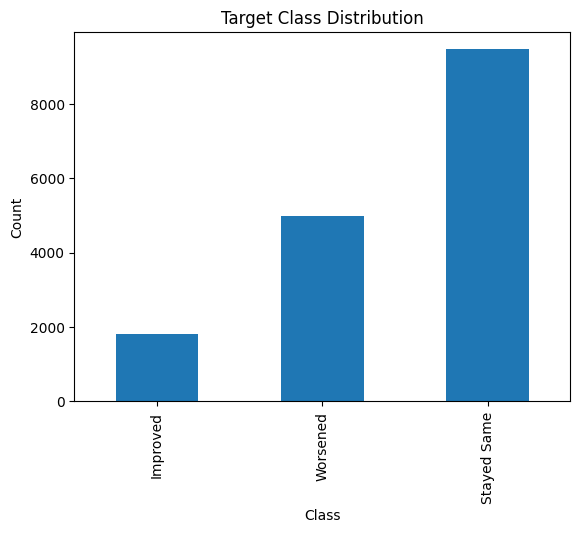

In [54]:
y = df[TARGET_COL]
counts = y.value_counts().sort_index()
print(counts)

counts.rename(LABEL_MAP).plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## 6. Preprocessing: Missing Values & Data Types

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (12992, 11) Test size: (3249, 11)


In [56]:
# ---- Select features & target ONLY ----
X = df[FEATURES].copy()
y = df[TARGET_COL].copy()

# ensure numeric columns are numeric (SAFE before split)
numeric_cols = [c for c in FEATURES if c not in CATEGORICAL_COLS]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X.isna().sum()

PAGEMIEG    0
PPVRES      0
PEDUCMIE    0
PEFATINC    0
PFTENUR     0
PWDPRMOR    0
PWDSLOAN    0
PWDSTCRD    0
PWDSTLOC    0
PWASTDEP    0
PWATFS      0
dtype: int64

## 7. Model: Train/Test Split & Logistic Regression Pipeline

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="drop",
)

model = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    class_weight="balanced"
)

pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", model)
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [58]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [59]:
y_pred = pipe.predict(X_test)

In [60]:
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
macro = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(acc, 3))
print("Balanced Accuracy:", round(bacc, 3))
print("Macro F1:", round(macro, 3))

Accuracy: 0.482
Balanced Accuracy: 0.489
Macro F1: 0.438


In [61]:
print(classification_report(
    y_test, y_pred,
    target_names=list(LABEL_MAP.values()),
    digits=3
))

              precision    recall  f1-score   support

    Improved      0.204     0.556     0.298       360
    Worsened      0.451     0.400     0.424       998
 Stayed Same      0.700     0.512     0.592      1891

    accuracy                          0.482      3249
   macro avg      0.452     0.489     0.438      3249
weighted avg      0.569     0.482     0.507      3249



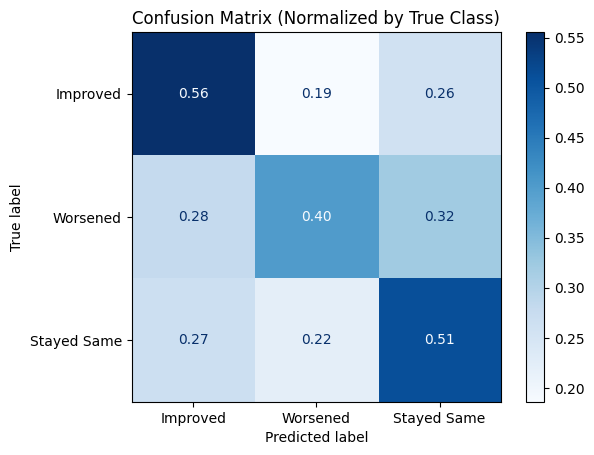

In [62]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=list(LABEL_MAP.values()),
    normalize="true",
    cmap="Blues",
    values_format=".2f"
)
plt.title("Confusion Matrix (Normalized by True Class)")
plt.show()

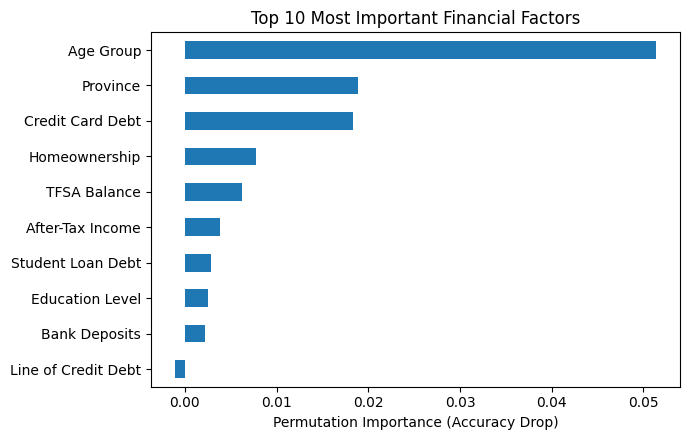

In [63]:
# -------------------------------
# Readable feature names
# -------------------------------
READABLE_NAMES = {
    "PAGEMIEG": "Age Group",
    "PPVRES": "Province",
    "PEDUCMIE": "Education Level",
    "PEFATINC": "After-Tax Income",
    "PFTENUR": "Homeownership",
    "PWDPRMOR": "Mortgage Debt",
    "PWDSLOAN": "Student Loan Debt",
    "PWDSTCRD": "Credit Card Debt",
    "PWDSTLOC": "Line of Credit Debt",
    "PWASTDEP": "Bank Deposits",
    "PWATFS": "TFSA Balance",
}

# -------------------------------
# Compute permutation importance
# -------------------------------
result = permutation_importance(
    pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

# -------------------------------
# Convert to Series
# -------------------------------
imp = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

# -------------------------------
# Replace code names with readable names
# -------------------------------
imp = imp.rename(index=READABLE_NAMES)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(7,4.5))

imp.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Most Important Financial Factors")
plt.xlabel("Permutation Importance (Accuracy Drop)")
plt.tight_layout()
plt.show()

## 8. Model Inference Demo (Example Prediction)

In [64]:
# Code Demo
example_user = {
    "PAGEMIEG": 2,
    "PPVRES": 35,
    "PEDUCMIE": 4,
    "PEFATINC": 60000,
    "PFTENUR": 2,
    "PWDPRMOR": 200000,
    "PWDSLOAN": 10000,
    "PWDSTCRD": 2000,
    "PWDSTLOC": 5000,
    "PWASTDEP": 8000,
    "PWATFS": 12000
}

user_df = pd.DataFrame([example_user], columns=FEATURES)
proba = pipe.predict_proba(user_df)[0]
classes = pipe.named_steps["clf"].classes_

for cls, p in zip(classes, proba):
    print(LABEL_MAP[int(cls)], ":", round(float(p), 3))

pred = pipe.predict(user_df)[0]
print("Predicted:", LABEL_MAP[int(pred)])

Improved : 0.467
Worsened : 0.361
Stayed Same : 0.172
Predicted: Improved
